# Google Sheets for Rainfall_0000 Data: https://docs.google.com/spreadsheets/d/1FgQRhw9HWl-7XXXsmWhnBUNeneZqLjEzmYZBD_2KLuo/edit?gid=0#gid=0

In [17]:
import pandas as pd # process and manipulate table data, implementing operations such as loading, aligning, merging, and transforming datasets efficiently
import numpy as np # numerical computing library for working with arrays and matrices, providing mathematical functions to operate on these data structures
import matplotlib.pyplot as plt # plotting library for creating static, animated, and interactive visualizations in Python
import os   # operating system interfaces for file and directory manipulation
import warnings # warning control to suppress or manage warning messages

from tkinter import Tk # standard GUI library for Python, used here to create file dialog windows
from tkinter.filedialog import askopenfilenames # function to open file dialog for selecting multiple files

# Suppress pandas parsing warnings
warnings.filterwarnings('ignore', message="Could not infer format") 

Loading and processing rainfall data...
  CORMP: 1161 hourly records
  Davis: 1192 hourly records
  rainfall_0000: 1212 hourly records

Filtering to period: 2025-12-19 09:00:00 to 2026-02-05 09:00:00
  CORMP (filtered): 1153 records
  Davis (filtered): 1153 records
  rainfall_0000 (filtered): 1154 records


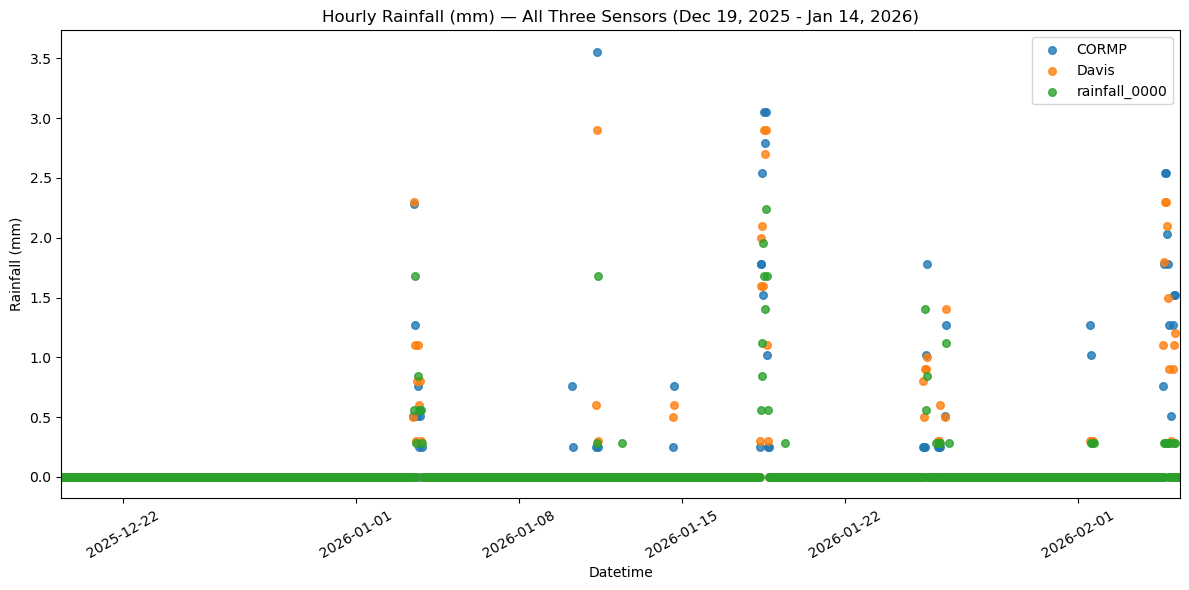

In [18]:

# STEP 1: Define file paths and helper functions
# Earliest data from rainfall_0000 is Dec 19, 2025, therefore all graphs begin at this time stamp.
file_1 = "Data/precip_CORMP_02052026.csv"   # needs hourly sum
file_2 = "Data/precip_Davis_02052026.csv"   # needs hourly sum
file_3 = "Data/rainfall_0000_02052026.csv"   # already hourly

import io # for in-memory file operations
import re # for regular expressions

# detects header row by looking for keywords in the first max_lines (200) lines
# looking for for keywords like 'date' or 'time', combined with a comma (typical CSV header indicator).
def detect_header_row(path, max_lines=200):
    with open(path, 'r', encoding='utf-8', errors='ignore') as fh:
        for i, line in enumerate(fh):
            if i >= max_lines:
                break
            low = line.lower()
            # looking for header lines usually contain 'date' or 'time' and a comma
            if (('date' in low or 'time' in low) and ',' in line) or ('date &' in low):
                return i
    return 0


# Load and process rainfall_0 CSV file with "smart column detection". Returns data from datetime and rainfall 
# Converts units if needed, and resamples to hourly aggregates.
def load_and_process(filepath, assume_inches=False, already_hourly=False, parse_embedded_string=False):
    path = os.path.join(filepath)
    
    # Special handling for rainfall_0000 format: use header=None to preserve comma-separated string values
    if parse_embedded_string:
        df = pd.read_csv(path, header=None, engine='python')
        # Assign column names for embedded string format
        df.columns = ['Device_ID', 'Datetime', 'Sensor', 'Event', 'Data']
        dtcol = 'Datetime'
        rcol = 'Data'
    else:
        header_row = detect_header_row(path, max_lines=200)
        try:
            # set header to detected row; also skip percent-comment lines
            df = pd.read_csv(path, header=header_row, comment='%', engine='python')
        except Exception as e:
            print(f"read_csv failed for {path}: {e}")
            df = pd.read_csv(path, engine='python', sep=None, on_bad_lines='warn')

        # ensure column names are strings
        df.columns = [str(c) for c in df.columns]

        # find datetime column by keywords or by attempting to parse columns
        datetime_cols = [c for c in df.columns if any(k in c.lower() for k in ('date','time','datetime','timestamp'))]
        dtcol = None
        if datetime_cols: # found by keyword
            dtcol = datetime_cols[0]
        else:
            for c in df.columns:
                try:
                    parsed = pd.to_datetime(df[c], errors='coerce') # try to parse as datetime
                    if parsed.notna().sum() > 0: # at least some valid datetimes
                        dtcol = c
                        break
                except Exception:
                    continue
        if dtcol is None:
            raise ValueError(f"No datetime-like column found in {filepath}")

        # find rainfall column
        rain_cols = [c for c in df.columns if any(k in c.lower() for k in ('rain','precip','mm','inches'))]
        if rain_cols:
            rcol = rain_cols[0]
        else:
            numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
            rcol = numeric_cols[0] if numeric_cols else None

        if rcol is None:
            for c in df.columns:
                coerced = pd.to_numeric(df[c], errors='coerce')
                if coerced.notna().sum() > 0:
                    rcol = c
                    df[c] = coerced
                    break
        if rcol is None:
            raise ValueError(f"No rainfall/numeric column found in {filepath}")

    df['datetime'] = pd.to_datetime(df[dtcol], errors='coerce')

    # Special handling for rainfall_0000 format: extract rainfall value from comma-separated string (3rd value)
    if parse_embedded_string:
        def extract_rain_value(val):
            try:
                if pd.isna(val):
                    return np.nan
                val_str = str(val).strip().strip('"')  # remove quotes if present
                parts = [p.strip() for p in val_str.split(',')]
                if len(parts) > 2:
                    return float(parts[2])  # 3rd value (index 2) is rainfall in mm
                else:
                    return np.nan
            except:
                return np.nan
        df['rain_mm'] = df[rcol].apply(extract_rain_value)
        rcol = 'rain_mm'
    else:
        df[rcol] = pd.to_numeric(df[rcol], errors='coerce')
        if assume_inches:
            df[rcol] = df[rcol] * 25.4

    subset_cols = [c for c in ['datetime', rcol] if c in df.columns]
    df = df.dropna(subset=subset_cols)

    if 'datetime' in df.columns:
        df = df.set_index('datetime')
    else:
        if not isinstance(df.index, pd.DatetimeIndex):
            raise KeyError('datetime')

    if already_hourly:
        hourly = df.reset_index().rename(columns={rcol: 'rain_mm'})
        if 'datetime' not in hourly.columns:
            hourly = hourly.rename(columns={hourly.columns[0]: 'datetime'})
    else:
        hourly = df[rcol].resample('h').sum().reset_index().rename(columns={rcol: 'rain_mm'})
    return hourly


# STEP 2: Load and process all three rainfall files

print("Loading and processing rainfall data...")
cormp = load_and_process(file_1, assume_inches=True, already_hourly=False)
davis = load_and_process(file_2, assume_inches=False, already_hourly=False)
rain0 = load_and_process(file_3, assume_inches=False, already_hourly=True, parse_embedded_string=True)

print(f"  CORMP: {len(cormp)} hourly records")
print(f"  Davis: {len(davis)} hourly records")
print(f"  rainfall_0000: {len(rain0)} hourly records")


# STEP 3: Filter to the analysis date range (Dec 19, 2025 - Jan 6, 2026)

start = pd.to_datetime('2025-12-19 09:00')
end = pd.to_datetime('2026-02-05 9:00')

print(f"\nFiltering to period: {start} to {end}")

cormp = cormp[(cormp['datetime'] >= start) & (cormp['datetime'] <= end)].reset_index(drop=True)
davis = davis[(davis['datetime'] >= start) & (davis['datetime'] <= end)].reset_index(drop=True)
rain0 = rain0[(rain0['datetime'] >= start) & (rain0['datetime'] <= end)].reset_index(drop=True)

print(f"  CORMP (filtered): {len(cormp)} records")
print(f"  Davis (filtered): {len(davis)} records")
print(f"  rainfall_0000 (filtered): {len(rain0)} records")

# STEP 4: Plot - All three sensors over full date range

plt.figure(figsize=(12,6))
if not cormp.empty:
    plt.scatter(cormp['datetime'], cormp['rain_mm'], label='CORMP', s=30, alpha=0.8)
if not davis.empty:
    plt.scatter(davis['datetime'], davis['rain_mm'], label='Davis', s=30, alpha=0.8)
if not rain0.empty:
    plt.scatter(rain0['datetime'], rain0['rain_mm'], label='rainfall_0000', s=30, alpha=0.8)

plt.xlabel('Datetime')
plt.ylabel('Rainfall (mm)')
plt.title('Hourly Rainfall (mm) — All Three Sensors (Dec 19, 2025 - Jan 14, 2026)')
plt.legend()
plt.xlim(start, end)

plt.xticks(rotation=30)
plt.tight_layout()
plt.show()


FULL PERIOD ANALYSIS: CORMP vs Davis and rainfall_0000
December 19th, 2025 - February 5th, 2026

Data summary:
  CORMP records: 1153
  Davis records: 1153
  rainfall_0000 records: 1154

Merged dataset shape: (1160, 9)

CORP vs Davis:
  Pearson Correlation: 0.9694
  R²: 0.9397
  Slope: 0.8961

CORP vs rainfall_0000:
  Pearson Correlation: 0.6693
  R²: 0.4480
  Slope: 0.3709

Generating scatter plot...
  Plotted 1160 CORMP data points
  Plotted 1160 Davis data points
  Plotted 1154 rainfall_0000 data points


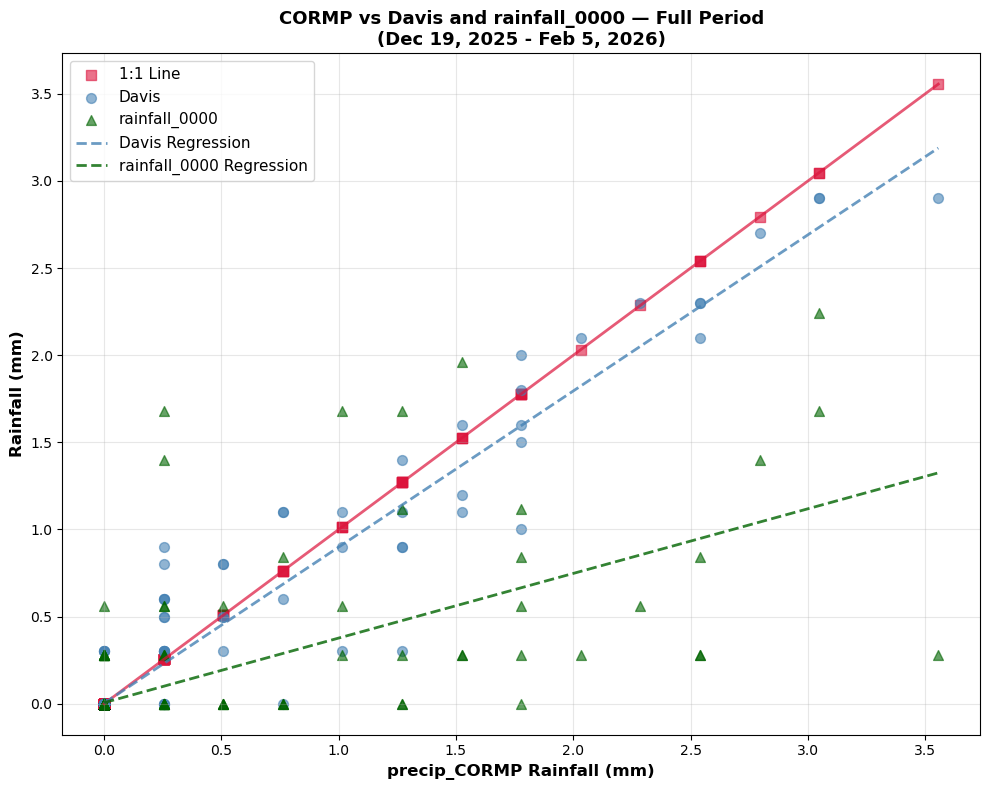

In [19]:
# CORMP (X-axis) vs Davis and rainfall_0000 (Y-axis) — Full Period Comparison
# December 19th, 2025 - February 5th, 2026

print("=" * 70)
print("FULL PERIOD ANALYSIS: CORMP vs Davis and rainfall_0000")
print("December 19th, 2025 - February 5th, 2026")
print("=" * 70)

# Use the already-filtered datasets from the initial load
print(f"\nData summary:")
print(f"  CORMP records: {len(cormp)}")
print(f"  Davis records: {len(davis)}")
print(f"  rainfall_0000 records: {len(rain0)}")

# Round all to nearest HOUR for alignment
cormp_full = cormp.copy()
davis_full = davis.copy()
rain0_full = rain0.copy()

cormp_full['datetime'] = cormp_full['datetime'].dt.floor('h')
davis_full['datetime'] = davis_full['datetime'].dt.floor('h')
rain0_full['datetime'] = rain0_full['datetime'].dt.floor('h')

# Merge datasets on datetime
merged_full = pd.merge(cormp_full, davis_full, on='datetime', how='outer', suffixes=('_cormp','_davis'))
merged_full = pd.merge(merged_full, rain0_full, on='datetime', how='outer')
merged_full = merged_full.rename(columns={'rain_mm': 'rain_mm_rain0'})

print(f"\nMerged dataset shape: {merged_full.shape}")

# Compute correlations and statistics
if not merged_full.empty:
    from scipy import stats
    
    # CORMP vs Davis
    cormp_davis_data = merged_full[merged_full['rain_mm_cormp'].notna() & merged_full['rain_mm_davis'].notna()]
    if not cormp_davis_data.empty:
        corr_cd = cormp_davis_data['rain_mm_cormp'].corr(cormp_davis_data['rain_mm_davis'])
        r2_cd = corr_cd**2
        slope_cd, intercept_cd, _, _, _ = stats.linregress(cormp_davis_data['rain_mm_cormp'], cormp_davis_data['rain_mm_davis'])
        print(f"\nCORP vs Davis:")
        print(f"  Pearson Correlation: {corr_cd:.4f}")
        print(f"  R²: {r2_cd:.4f}")
        print(f"  Slope: {slope_cd:.4f}")
    
    # CORMP vs rainfall_0000
    cormp_rain0_data = merged_full[merged_full['rain_mm_cormp'].notna() & merged_full['rain_mm_rain0'].notna()]
    if not cormp_rain0_data.empty:
        corr_cr = cormp_rain0_data['rain_mm_cormp'].corr(cormp_rain0_data['rain_mm_rain0'])
        r2_cr = corr_cr**2
        slope_cr, intercept_cr, _, _, _ = stats.linregress(cormp_rain0_data['rain_mm_cormp'], cormp_rain0_data['rain_mm_rain0'])
        print(f"\nCORP vs rainfall_0000:")
        print(f"  Pearson Correlation: {corr_cr:.4f}")
        print(f"  R²: {r2_cr:.4f}")
        print(f"  Slope: {slope_cr:.4f}")

# Create scatter plot: CORMP (X-axis) vs Davis and rainfall_0000 (Y-axis)
print(f"\nGenerating scatter plot...")
plt.figure(figsize=(10, 8))

if not merged_full.empty:
    # Plot CORMP data (1:1 line)
    cormp_data = merged_full[merged_full['rain_mm_cormp'].notna()]
    if not cormp_data.empty:
        plt.scatter(cormp_data['rain_mm_cormp'], cormp_data['rain_mm_cormp'], 
                   s=50, alpha=0.6, color='crimson', label='1:1 Line', marker='s')
        # Draw line through CORMP data
        cormp_sorted = cormp_data.sort_values('rain_mm_cormp')
        plt.plot(cormp_sorted['rain_mm_cormp'], cormp_sorted['rain_mm_cormp'], 
                color='crimson', linewidth=2, alpha=0.7)
        print(f"  Plotted {len(cormp_data)} CORMP data points")
    
    # Plot Davis data
    davis_data = merged_full[merged_full['rain_mm_davis'].notna()]
    if not davis_data.empty:
        plt.scatter(davis_data['rain_mm_cormp'], davis_data['rain_mm_davis'], 
                   s=50, alpha=0.6, color='steelblue', label='Davis', marker='o')
        print(f"  Plotted {len(davis_data)} Davis data points")
    
    # Plot rainfall_0000 data
    rain0_data = merged_full[merged_full['rain_mm_rain0'].notna()]
    if not rain0_data.empty:
        plt.scatter(rain0_data['rain_mm_cormp'], rain0_data['rain_mm_rain0'], 
                   s=50, alpha=0.6, color='darkgreen', label='rainfall_0000', marker='^')
        print(f"  Plotted {len(rain0_data)} rainfall_0000 data points")
    
    # Add linear regression lines
    # Get x-axis range for regression line plotting
    all_x = []
    if not cormp_data.empty:
        all_x.extend(cormp_data['rain_mm_cormp'].values)
    if not davis_data.empty:
        all_x.extend(davis_data['rain_mm_cormp'].values)
    if not rain0_data.empty:
        all_x.extend(rain0_data['rain_mm_cormp'].values)
    
    if all_x:
        x_min, x_max = min(all_x), max(all_x)
        x_line = np.array([x_min, x_max])
        
        # Davis regression line
        if not cormp_davis_data.empty:
            y_davis = slope_cd * x_line + intercept_cd
            plt.plot(x_line, y_davis, color='steelblue', linewidth=2, alpha=0.8, linestyle='--', label='Davis Regression')
        
        # rainfall_0000 regression line
        if not cormp_rain0_data.empty:
            y_rain0 = slope_cr * x_line + intercept_cr
            plt.plot(x_line, y_rain0, color='darkgreen', linewidth=2, alpha=0.8, linestyle='--', label='rainfall_0000 Regression')

plt.xlabel('precip_CORMP Rainfall (mm)', fontsize=12, fontweight='bold')
plt.ylabel('Rainfall (mm)', fontsize=12, fontweight='bold')
plt.title('CORMP vs Davis and rainfall_0000 — Full Period\n(Dec 19, 2025 - Feb 5, 2026)', fontsize=13, fontweight='bold')
plt.legend(loc='upper left', fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

FULL PERIOD ANALYSIS: CORMP vs rainfall_0000 Only
December 19th, 2025 - February 5th, 2026

Data summary:
  CORMP records: 1153
  rainfall_0000 records: 1154

Merged dataset shape: (1160, 8)

CORMP vs rainfall_0000:
  Pearson Correlation: 0.6693
  R²: 0.4480
  Slope: 0.3709

Generating scatter plot...
  Plotted 1160 CORMP data points
  Plotted 1154 rainfall_0000 data points


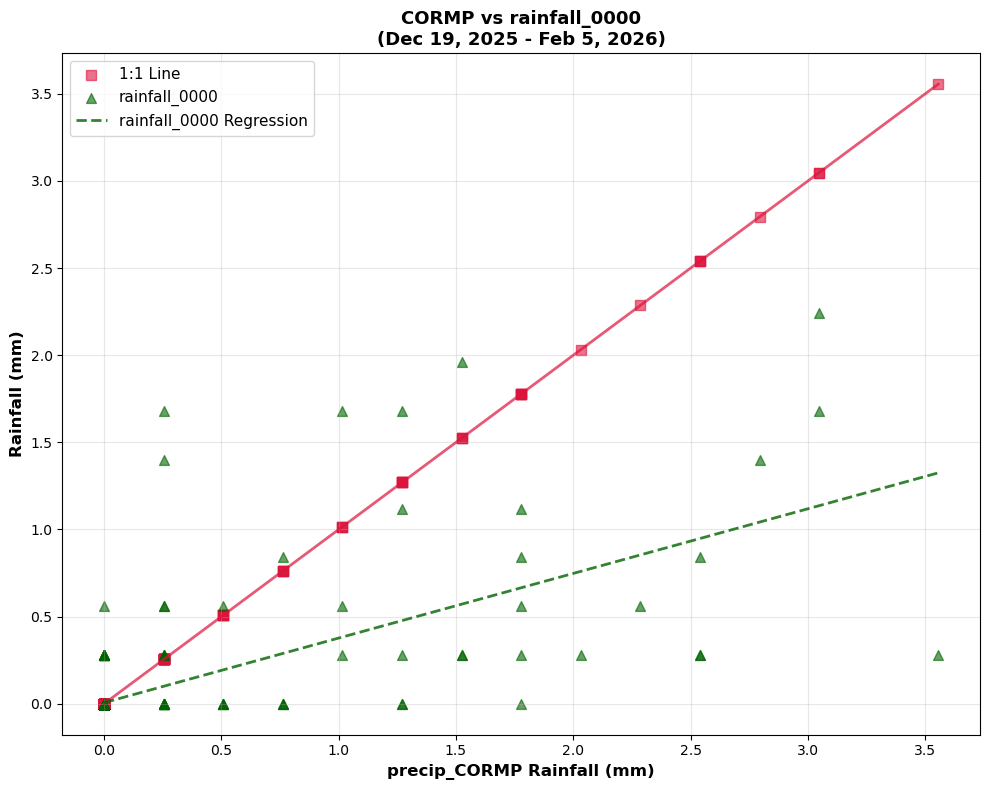

In [20]:
# CORMP (X-axis) vs rainfall_0000 (Y-axis) — Full Period Comparison
# December 19th, 2025 - February 5th, 2026

print("=" * 70)
print("FULL PERIOD ANALYSIS: CORMP vs rainfall_0000 Only")
print("December 19th, 2025 - February 5th, 2026")
print("=" * 70)

# Use the already-filtered datasets from the initial load
print(f"\nData summary:")
print(f"  CORMP records: {len(cormp)}")
print(f"  rainfall_0000 records: {len(rain0)}")

# Round all to nearest HOUR for alignment
cormp_full_rain0 = cormp.copy()
rain0_full_only = rain0.copy()

cormp_full_rain0['datetime'] = cormp_full_rain0['datetime'].dt.floor('h')
rain0_full_only['datetime'] = rain0_full_only['datetime'].dt.floor('h')

# Merge datasets on datetime
merged_rain0_only = pd.merge(cormp_full_rain0, rain0_full_only, on='datetime', how='outer', suffixes=('_cormp','_rain0'))

print(f"\nMerged dataset shape: {merged_rain0_only.shape}")

# Compute correlations and statistics
if not merged_rain0_only.empty:
    from scipy import stats
    
    # CORMP vs rainfall_0000
    cormp_rain0_data_only = merged_rain0_only[merged_rain0_only['rain_mm_cormp'].notna() & merged_rain0_only['rain_mm_rain0'].notna()]
    if not cormp_rain0_data_only.empty:
        corr_cr_only = cormp_rain0_data_only['rain_mm_cormp'].corr(cormp_rain0_data_only['rain_mm_rain0'])
        r2_cr_only = corr_cr_only**2
        slope_cr_only, intercept_cr_only, _, _, _ = stats.linregress(cormp_rain0_data_only['rain_mm_cormp'], cormp_rain0_data_only['rain_mm_rain0'])
        print(f"\nCORMP vs rainfall_0000:")
        print(f"  Pearson Correlation: {corr_cr_only:.4f}")
        print(f"  R²: {r2_cr_only:.4f}")
        print(f"  Slope: {slope_cr_only:.4f}")

# Create scatter plot: CORMP (X-axis) vs rainfall_0000 (Y-axis)
print(f"\nGenerating scatter plot...")
plt.figure(figsize=(10, 8))

if not merged_rain0_only.empty:
    # Plot CORMP data (1:1 line)
    cormp_data_rain0 = merged_rain0_only[merged_rain0_only['rain_mm_cormp'].notna()]
    if not cormp_data_rain0.empty:
        plt.scatter(cormp_data_rain0['rain_mm_cormp'], cormp_data_rain0['rain_mm_cormp'], 
                   s=50, alpha=0.6, color='crimson', label='1:1 Line', marker='s')
        # Draw line through CORMP data
        cormp_sorted_rain0 = cormp_data_rain0.sort_values('rain_mm_cormp')
        plt.plot(cormp_sorted_rain0['rain_mm_cormp'], cormp_sorted_rain0['rain_mm_cormp'], 
                color='crimson', linewidth=2, alpha=0.7)
        print(f"  Plotted {len(cormp_data_rain0)} CORMP data points")
    
    # Plot rainfall_0000 data
    rain0_data_only = merged_rain0_only[merged_rain0_only['rain_mm_rain0'].notna()]
    if not rain0_data_only.empty:
        plt.scatter(rain0_data_only['rain_mm_cormp'], rain0_data_only['rain_mm_rain0'], 
                   s=50, alpha=0.6, color='darkgreen', label='rainfall_0000', marker='^')
        print(f"  Plotted {len(rain0_data_only)} rainfall_0000 data points")
    
    # Add linear regression line for rainfall_0000
    all_x_rain0 = []
    if not cormp_data_rain0.empty:
        all_x_rain0.extend(cormp_data_rain0['rain_mm_cormp'].values)
    if not rain0_data_only.empty:
        all_x_rain0.extend(rain0_data_only['rain_mm_cormp'].values)
    
    if all_x_rain0:
        x_min_rain0, x_max_rain0 = min(all_x_rain0), max(all_x_rain0)
        x_line_rain0 = np.array([x_min_rain0, x_max_rain0])
        
        # rainfall_0000 regression line
        if not cormp_rain0_data_only.empty:
            y_rain0_only = slope_cr_only * x_line_rain0 + intercept_cr_only
            plt.plot(x_line_rain0, y_rain0_only, color='darkgreen', linewidth=2, alpha=0.8, linestyle='--', label='rainfall_0000 Regression')

plt.xlabel('precip_CORMP Rainfall (mm)', fontsize=12, fontweight='bold')
plt.ylabel('Rainfall (mm)', fontsize=12, fontweight='bold')
plt.title('CORMP vs rainfall_0000\n(Dec 19, 2025 - Feb 5, 2026)', fontsize=13, fontweight='bold')
plt.legend(loc='upper left', fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


Filtering January 3rd data...
  CORMP: 24 hourly records
  Davis: 24 hourly records
  rainfall_0000: 24 hourly records


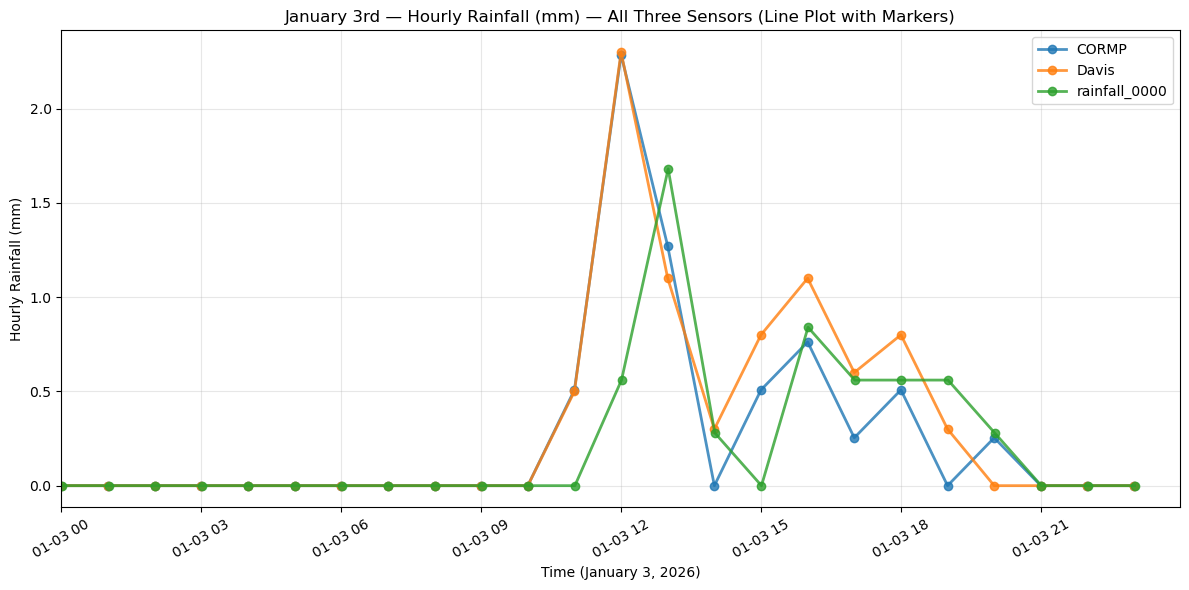

In [21]:

# View of January 3rd, 2026 — All three sensors

jan3_start = pd.to_datetime('2026-01-03 00:00')
jan3_end = pd.to_datetime('2026-01-03 23:59')

print("Filtering January 3rd data...")
cormp_jan3 = cormp[(cormp['datetime'] >= jan3_start) & (cormp['datetime'] <= jan3_end)].reset_index(drop=True)
davis_jan3 = davis[(davis['datetime'] >= jan3_start) & (davis['datetime'] <= jan3_end)].reset_index(drop=True)
rain0_jan3 = rain0[(rain0['datetime'] >= jan3_start) & (rain0['datetime'] <= jan3_end)].reset_index(drop=True)

print(f"  CORMP: {len(cormp_jan3)} hourly records")
print(f"  Davis: {len(davis_jan3)} hourly records")
print(f"  rainfall_0000: {len(rain0_jan3)} hourly records")

plt.figure(figsize=(12,6))
if not cormp_jan3.empty:
    plt.plot(cormp_jan3['datetime'], cormp_jan3['rain_mm'], label='CORMP', marker='o', linewidth=2, markersize=6, alpha=0.8)
if not davis_jan3.empty:
    plt.plot(davis_jan3['datetime'], davis_jan3['rain_mm'], label='Davis', marker='o', linewidth=2, markersize=6, alpha=0.8)
if not rain0_jan3.empty:
    plt.plot(rain0_jan3['datetime'], rain0_jan3['rain_mm'], label='rainfall_0000', marker='o', linewidth=2, markersize=6, alpha=0.8)

plt.xlabel('Time (January 3, 2026)')
plt.ylabel('Hourly Rainfall (mm)')
plt.title('January 3rd — Hourly Rainfall (mm) — All Three Sensors (Line Plot with Markers)')
plt.legend()
plt.xlim(jan3_start, jan3_end)
plt.xticks(rotation=30)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


ANALYSIS 2: Davis vs rainfall_0000 Comparison

Before datetime alignment:
  Davis shape: (627, 2)
  rainfall_0000 shape: (626, 7)

Overlapping hourly timestamps: 625 hours
Merged dataset shape: (626, 8)

Pearson Correlation: 0.5223
R² (Coefficient of Determination): 0.2728
RMSE (Root Mean Square Error): 0.1481 mm
Slope: 0.3404

Generating scatter plot...
  Plotted 626 data points


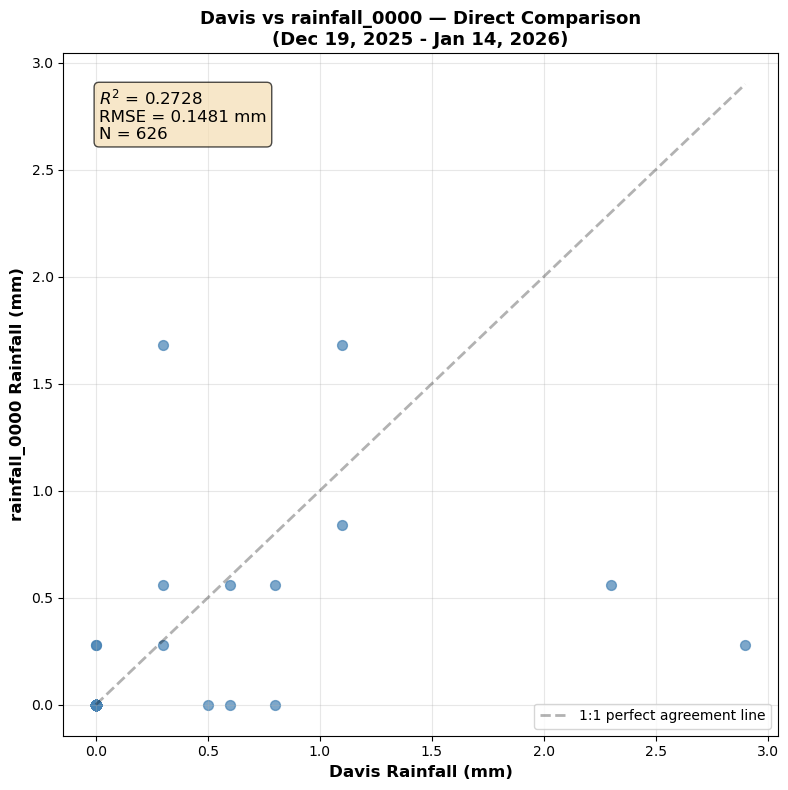

In [22]:
# Davis vs rainfall_0000 — Direct Sensor Comparison
# Merge datasets by datetime, compute correlation (R²), and plot


print("=" * 70)
print("ANALYSIS 2: Davis vs rainfall_0000 Comparison")
print("=" * 70)

# Reload and process both datasets for clean analysis
davis_only = load_and_process(file_2, assume_inches=False, already_hourly=False)
rain0_only = load_and_process(file_3, assume_inches=False, already_hourly=True, parse_embedded_string=True)

start = pd.to_datetime('2025-12-19 09:00')
end = pd.to_datetime('2026-01-14 11:00')

davis_only = davis_only[(davis_only['datetime'] >= start) & (davis_only['datetime'] <= end)].reset_index(drop=True)
rain0_only = rain0_only[(rain0_only['datetime'] >= start) & (rain0_only['datetime'] <= end)].reset_index(drop=True)

print(f"\nBefore datetime alignment:")
print(f"  Davis shape: {davis_only.shape}")
print(f"  rainfall_0000 shape: {rain0_only.shape}")

# Round both to nearest HOUR to align hourly data (discard minutes and seconds)
# This ensures datasets can be merged properly on datetime
davis_only['datetime'] = davis_only['datetime'].dt.floor('h')
rain0_only['datetime'] = rain0_only['datetime'].dt.floor('h')

# Check for overlapping datetimes
davis_dates = set(davis_only['datetime'])
rain0_dates = set(rain0_only['datetime'])
overlap = davis_dates.intersection(rain0_dates)
print(f"\nOverlapping hourly timestamps: {len(overlap)} hours")

# Align datasets on datetime for direct comparison
merged_dr_only = pd.merge(davis_only, rain0_only, on='datetime', how='inner', suffixes=('_davis','_rain0'))
print(f"Merged dataset shape: {merged_dr_only.shape}")

# Compute correlation, R², RMSE, and slope
if not merged_dr_only.empty:
    from scipy import stats
    corr_only = merged_dr_only['rain_mm_davis'].corr(merged_dr_only['rain_mm_rain0'])
    r2_only = corr_only**2 if pd.notna(corr_only) else float('nan')
    # Calculate RMSE (Root Mean Square Error)
    mse = np.mean((merged_dr_only['rain_mm_davis'] - merged_dr_only['rain_mm_rain0'])**2)
    rmse_only = np.sqrt(mse)
    # Calculate slope via linear regression
    slope_only, intercept_only, _, _, _ = stats.linregress(merged_dr_only['rain_mm_davis'], merged_dr_only['rain_mm_rain0'])
    print(f"\nPearson Correlation: {corr_only:.4f}")
    print(f"R² (Coefficient of Determination): {r2_only:.4f}")
    print(f"RMSE (Root Mean Square Error): {rmse_only:.4f} mm")
    print(f"Slope: {slope_only:.4f}")
else:
    r2_only = float('nan')
    rmse_only = float('nan')
    slope_only = float('nan')
    print("No overlapping data found!")

# Create scatter plot: Davis (X-axis) vs rainfall_0000 (Y-axis)
print(f"\nGenerating scatter plot...")
plt.figure(figsize=(8,8))
if not merged_dr_only.empty:
    plt.scatter(merged_dr_only['rain_mm_davis'], merged_dr_only['rain_mm_rain0'], s=50, alpha=0.7, color='steelblue')
    print(f"  Plotted {len(merged_dr_only)} data points")
else:
    print("  No data to plot - no overlapping datetimes found")

plt.xlabel('Davis Rainfall (mm)', fontsize=12, fontweight='bold')
plt.ylabel('rainfall_0000 Rainfall (mm)', fontsize=12, fontweight='bold')
plt.title('Davis vs rainfall_0000 — Direct Comparison\n(Dec 19, 2025 - Jan 14, 2026)', fontsize=13, fontweight='bold')

# Annotate R² and RMSE on plot
try:
    ax = plt.gca()
    if pd.notna(r2_only) and not merged_dr_only.empty:
        ax.text(0.05, 0.95, f'$R^2$ = {r2_only:.4f}\nRMSE = {rmse_only:.4f} mm\nN = {len(merged_dr_only)}', 
                transform=ax.transAxes, fontsize=12, va='top', 
                bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.7))
except Exception as e:
    print(f"Warning: Could not annotate plot: {e}")

if not merged_dr_only.empty:
    max_val = max(merged_dr_only['rain_mm_davis'].max(), merged_dr_only['rain_mm_rain0'].max())
    plt.plot([0, max_val], [0, max_val], 'k--', alpha=0.3, linewidth=2, label='1:1 perfect agreement line')
    plt.legend(loc='lower right')

plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

ANALYSIS 3: rainfall_0000 vs precip_CORMP Comparison

Before datetime alignment:
  CORMP shape: (627, 2)
  rainfall_0000 shape: (626, 7)

After rounding to nearest hour:
  CORMP first 5 timestamps: [Timestamp('2025-12-19 09:00:00'), Timestamp('2025-12-19 10:00:00'), Timestamp('2025-12-19 11:00:00'), Timestamp('2025-12-19 12:00:00'), Timestamp('2025-12-19 13:00:00')]
  rainfall_0000 first 5 timestamps: [Timestamp('2025-12-19 09:00:00'), Timestamp('2025-12-19 10:00:00'), Timestamp('2025-12-19 11:00:00'), Timestamp('2025-12-19 12:00:00'), Timestamp('2025-12-19 13:00:00')]

Overlapping hourly timestamps: 625 hours
Merged dataset shape: (626, 8)

Pearson Correlation: 0.4495
R² (Coefficient of Determination): 0.2021
Slope: 0.7456

Generating scatter plot...
  Plotted 626 data points


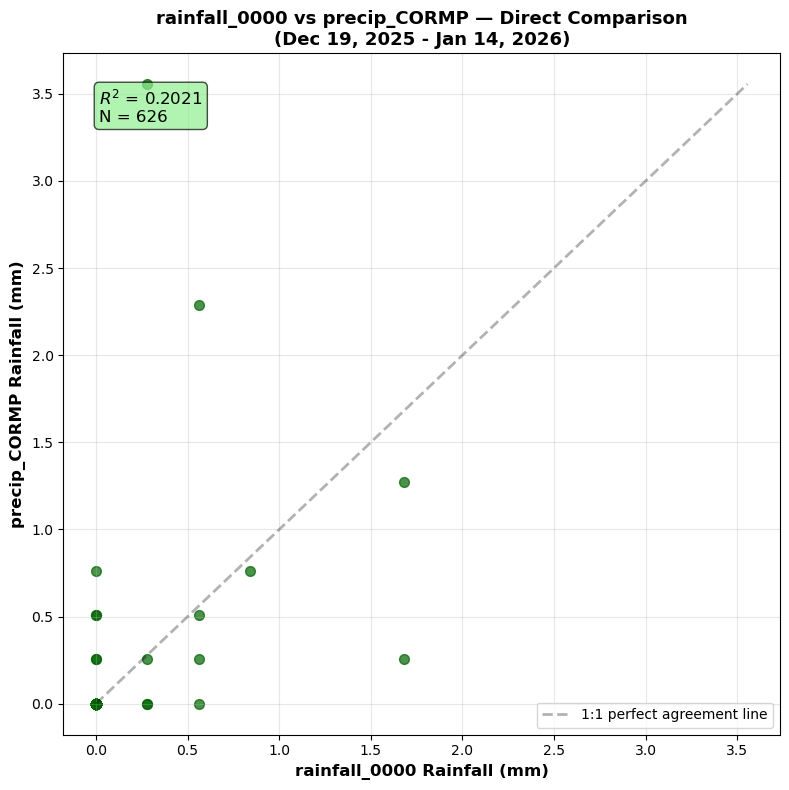

In [23]:
# Rainfall_0000 vs precip_CORMP — Direct Sensor Comparison
# Merge datasets by datetime, compute correlation (R²), and plot

print("=" * 70)
print("ANALYSIS 3: rainfall_0000 vs precip_CORMP Comparison")
print("=" * 70)

# Reload and process both datasets for clean analysis
cormp_only = load_and_process(file_1, assume_inches=True, already_hourly=False)
rain0_cormp = load_and_process(file_3, assume_inches=False, already_hourly=True, parse_embedded_string=True)

start = pd.to_datetime('2025-12-19 09:00')
end = pd.to_datetime('2026-01-14 11:00')

cormp_only = cormp_only[(cormp_only['datetime'] >= start) & (cormp_only['datetime'] <= end)].reset_index(drop=True)
rain0_cormp = rain0_cormp[(rain0_cormp['datetime'] >= start) & (rain0_cormp['datetime'] <= end)].reset_index(drop=True)

print(f"\nBefore datetime alignment:")
print(f"  CORMP shape: {cormp_only.shape}")
print(f"  rainfall_0000 shape: {rain0_cormp.shape}")

# Round both to nearest HOUR to align hourly data (discard minutes and seconds)
cormp_only['datetime'] = cormp_only['datetime'].dt.floor('h')
rain0_cormp['datetime'] = rain0_cormp['datetime'].dt.floor('h')

print(f"\nAfter rounding to nearest hour:")
print(f"  CORMP first 5 timestamps: {cormp_only['datetime'].head().tolist()}")
print(f"  rainfall_0000 first 5 timestamps: {rain0_cormp['datetime'].head().tolist()}")

# Check for overlapping datetimes
cormp_dates = set(cormp_only['datetime'])
rain0_dates = set(rain0_cormp['datetime'])
overlap = cormp_dates.intersection(rain0_dates)
print(f"\nOverlapping hourly timestamps: {len(overlap)} hours")

# Align datasets on datetime for direct comparison
merged_cr_only = pd.merge(rain0_cormp, cormp_only, on='datetime', how='inner', suffixes=('_rain0','_cormp'))
print(f"Merged dataset shape: {merged_cr_only.shape}")

# Compute correlation, R², and slope
if not merged_cr_only.empty:
    from scipy import stats
    corr_cr = merged_cr_only['rain_mm_rain0'].corr(merged_cr_only['rain_mm_cormp'])
    r2_cr = corr_cr**2 if pd.notna(corr_cr) else float('nan')
    # Calculate slope via linear regression
    slope_cr, intercept_cr, _, _, _ = stats.linregress(merged_cr_only['rain_mm_rain0'], merged_cr_only['rain_mm_cormp'])
    print(f"\nPearson Correlation: {corr_cr:.4f}")
    print(f"R² (Coefficient of Determination): {r2_cr:.4f}")
    print(f"Slope: {slope_cr:.4f}")
else:
    r2_cr = float('nan')
    slope_cr = float('nan')
    print("No overlapping data found!")

# Create scatter plot: rainfall_0000 (X-axis) vs precip_CORMP (Y-axis)
print(f"\nGenerating scatter plot...")
plt.figure(figsize=(8,8))
if not merged_cr_only.empty:
    plt.scatter(merged_cr_only['rain_mm_rain0'], merged_cr_only['rain_mm_cormp'], s=50, alpha=0.7, color='darkgreen')
    print(f"  Plotted {len(merged_cr_only)} data points")
else:
    print("  No data to plot - no overlapping datetimes found")

plt.xlabel('rainfall_0000 Rainfall (mm)', fontsize=12, fontweight='bold')
plt.ylabel('precip_CORMP Rainfall (mm)', fontsize=12, fontweight='bold')
plt.title('rainfall_0000 vs precip_CORMP — Direct Comparison\n(Dec 19, 2025 - Jan 14, 2026)', fontsize=13, fontweight='bold')

# Annotate R² on plot
try:
    ax = plt.gca()
    if pd.notna(r2_cr) and not merged_cr_only.empty:
        ax.text(0.05, 0.95, f'$R^2$ = {r2_cr:.4f}\nN = {len(merged_cr_only)}', 
                transform=ax.transAxes, fontsize=12, va='top', 
                bbox=dict(boxstyle='round', facecolor='lightgreen', alpha=0.7))
except Exception as e:
    print(f"Warning: Could not annotate plot: {e}")

if not merged_cr_only.empty:
    max_val = max(merged_cr_only['rain_mm_rain0'].max(), merged_cr_only['rain_mm_cormp'].max())
    plt.plot([0, max_val], [0, max_val], 'k--', alpha=0.3, linewidth=2, label='1:1 perfect agreement line')
    plt.legend(loc='lower right')

plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


ANALYSIS 4: precip_Davis vs precip_CORMP Comparison

Before datetime alignment:
  Davis shape: (627, 2)
  CORMP shape: (627, 2)

After rounding to nearest hour:
  Davis first 5 timestamps: [Timestamp('2025-12-19 09:00:00'), Timestamp('2025-12-19 10:00:00'), Timestamp('2025-12-19 11:00:00'), Timestamp('2025-12-19 12:00:00'), Timestamp('2025-12-19 13:00:00')]
  CORMP first 5 timestamps: [Timestamp('2025-12-19 09:00:00'), Timestamp('2025-12-19 10:00:00'), Timestamp('2025-12-19 11:00:00'), Timestamp('2025-12-19 12:00:00'), Timestamp('2025-12-19 13:00:00')]

Overlapping hourly timestamps: 627 hours
Merged dataset shape: (627, 3)

Pearson Correlation: 0.9560
R² (Coefficient of Determination): 0.9139
Slope: 1.0335

Generating scatter plot...
  Plotted 627 data points


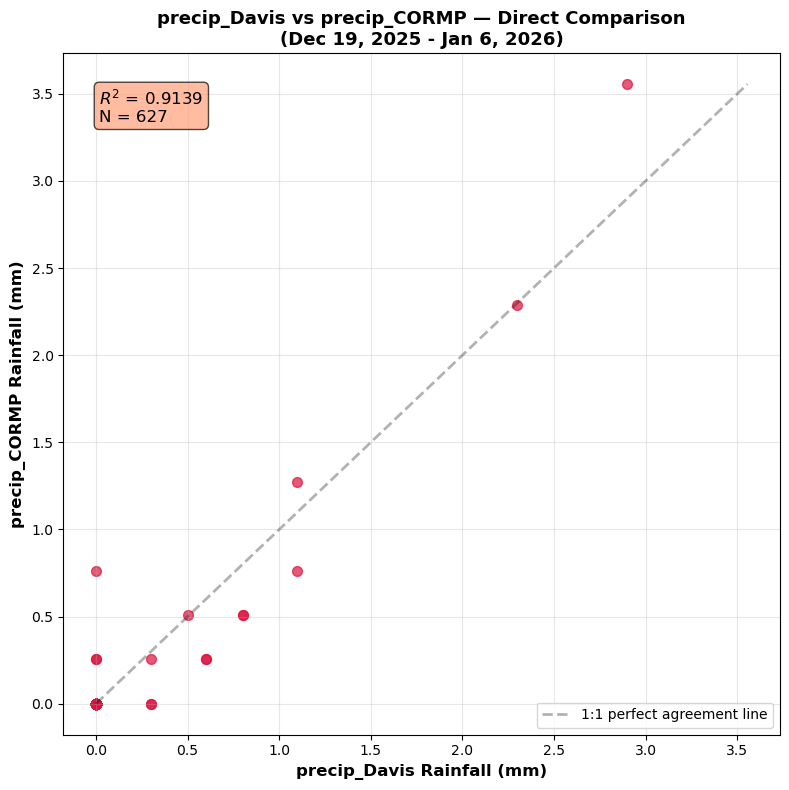

In [24]:
# precip_Davis vs precip_CORMP — Direct Sensor Comparison

print("=" * 70)
print("ANALYSIS 4: precip_Davis vs precip_CORMP Comparison")
print("=" * 70)

# Reload and process both datasets for clean analysis
davis_cormp = load_and_process(file_2, assume_inches=False, already_hourly=False)
cormp_davis = load_and_process(file_1, assume_inches=True, already_hourly=False)

start = pd.to_datetime('2025-12-19 09:00')
end = pd.to_datetime('2026-01-14 11:00')

davis_cormp = davis_cormp[(davis_cormp['datetime'] >= start) & (davis_cormp['datetime'] <= end)].reset_index(drop=True)
cormp_davis = cormp_davis[(cormp_davis['datetime'] >= start) & (cormp_davis['datetime'] <= end)].reset_index(drop=True)

print(f"\nBefore datetime alignment:")
print(f"  Davis shape: {davis_cormp.shape}")
print(f"  CORMP shape: {cormp_davis.shape}")

# Round both to nearest HOUR to align hourly data (discard minutes and seconds)
davis_cormp['datetime'] = davis_cormp['datetime'].dt.floor('h')
cormp_davis['datetime'] = cormp_davis['datetime'].dt.floor('h')

print(f"\nAfter rounding to nearest hour:")
print(f"  Davis first 5 timestamps: {davis_cormp['datetime'].head().tolist()}")
print(f"  CORMP first 5 timestamps: {cormp_davis['datetime'].head().tolist()}")

# Check for overlapping datetimes
davis_dates = set(davis_cormp['datetime'])
cormp_dates = set(cormp_davis['datetime'])
overlap = davis_dates.intersection(cormp_dates)
print(f"\nOverlapping hourly timestamps: {len(overlap)} hours")

# Align datasets on datetime for direct comparison
merged_dc_only = pd.merge(davis_cormp, cormp_davis, on='datetime', how='inner', suffixes=('_davis','_cormp'))
print(f"Merged dataset shape: {merged_dc_only.shape}")

# Compute correlation, R², and slope
if not merged_dc_only.empty:
    from scipy import stats
    corr_dc = merged_dc_only['rain_mm_davis'].corr(merged_dc_only['rain_mm_cormp'])
    r2_dc = corr_dc**2 if pd.notna(corr_dc) else float('nan')
    # Calculate slope via linear regression
    slope_dc, intercept_dc, _, _, _ = stats.linregress(merged_dc_only['rain_mm_davis'], merged_dc_only['rain_mm_cormp'])
    print(f"\nPearson Correlation: {corr_dc:.4f}")
    print(f"R² (Coefficient of Determination): {r2_dc:.4f}")
    print(f"Slope: {slope_dc:.4f}")
else:
    r2_dc = float('nan')
    slope_dc = float('nan')
    print("No overlapping data found!")

# Create scatter plot: precip_Davis (X-axis) vs precip_CORMP (Y-axis)
print(f"\nGenerating scatter plot...")
plt.figure(figsize=(8,8))
if not merged_dc_only.empty:
    plt.scatter(merged_dc_only['rain_mm_davis'], merged_dc_only['rain_mm_cormp'], s=50, alpha=0.7, color='crimson')
    print(f"  Plotted {len(merged_dc_only)} data points")
else:
    print("  No data to plot - no overlapping datetimes found")

plt.xlabel('precip_Davis Rainfall (mm)', fontsize=12, fontweight='bold')
plt.ylabel('precip_CORMP Rainfall (mm)', fontsize=12, fontweight='bold')
plt.title('precip_Davis vs precip_CORMP — Direct Comparison\n(Dec 19, 2025 - Jan 6, 2026)', fontsize=13, fontweight='bold')

# Annotate R² on plot
try:
    ax = plt.gca() # get current axes
    if pd.notna(r2_dc) and not merged_dc_only.empty:
        ax.text(0.05, 0.95, f'$R^2$ = {r2_dc:.4f}\nN = {len(merged_dc_only)}', 
                transform=ax.transAxes, fontsize=12, va='top', 
                bbox=dict(boxstyle='round', facecolor='lightsalmon', alpha=0.7))
except Exception as e:
    print(f"Warning: Could not annotate plot: {e}")

if not merged_dc_only.empty:
    max_val = max(merged_dc_only['rain_mm_davis'].max(), merged_dc_only['rain_mm_cormp'].max())
    plt.plot([0, max_val], [0, max_val], 'k--', alpha=0.3, linewidth=2, label='1:1 perfect agreement line')
    plt.legend(loc='lower right')

plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

ANALYSIS 5: January 18th, 2026 — CORMP vs Davis and rainfall_0000

January 18th, 2026 Data:
  CORMP records: 12
  Davis records: 12
  rainfall_0000 records: 11

Merged dataset shape: (12, 9)

Generating scatter plot...
  Plotted 12 CORMP data points
  Plotted 12 Davis data points
  Plotted 11 rainfall_0000 data points


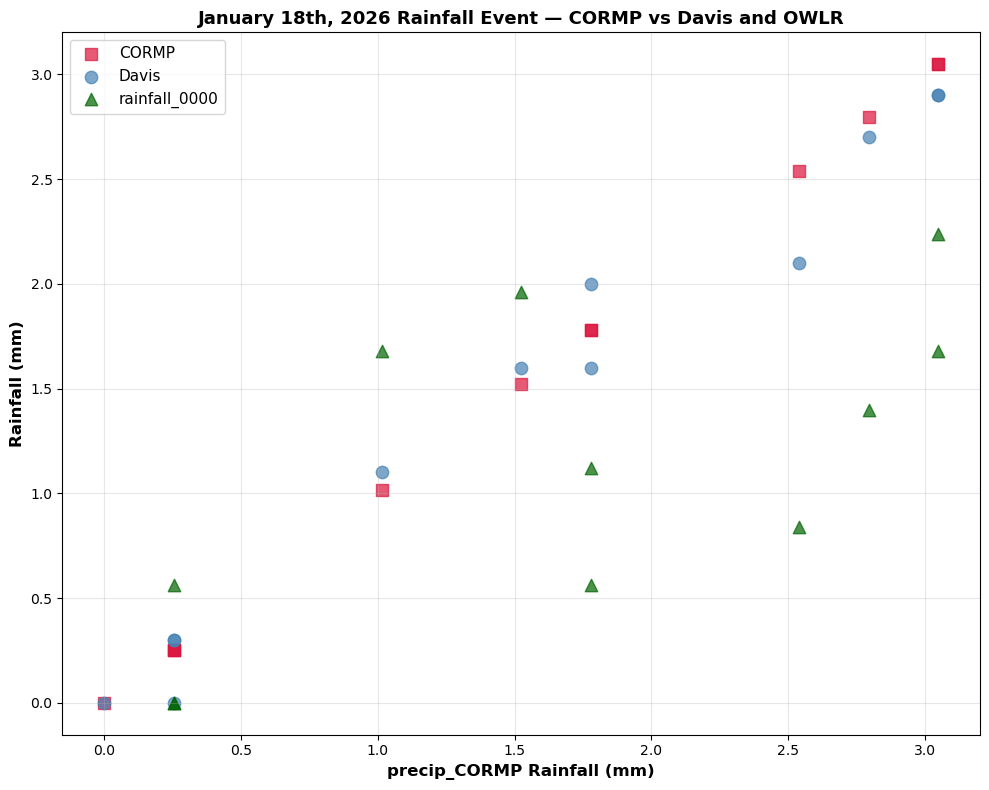


Summary Statistics for January 18th:
CORMP - Min: 0.0000, Max: 3.0480, Mean: 1.5240
Davis - Min: 0.0000, Max: 2.9000, Mean: 1.4583
rainfall_0000 - Min: 0.0000, Max: 2.2400, Mean: 1.0945


In [25]:
# January 18th, 2026 — CORMP vs Davis and rainfall_0000 Comparison

print("=" * 70)
print("ANALYSIS 5: January 18th, 2026 — CORMP vs Davis and rainfall_0000")
print("=" * 70)

# Reload and process all three datasets for clean analysis
cormp_jan18 = load_and_process(file_1, assume_inches=True, already_hourly=False)
davis_jan18 = load_and_process(file_2, assume_inches=False, already_hourly=False)
rain0_jan18 = load_and_process(file_3, assume_inches=False, already_hourly=True, parse_embedded_string=True)

jan18_start = pd.to_datetime('2026-01-18 08:00')
jan18_end = pd.to_datetime('2026-01-18 19:00')

cormp_jan18 = cormp_jan18[(cormp_jan18['datetime'] >= jan18_start) & (cormp_jan18['datetime'] <= jan18_end)].reset_index(drop=True)
davis_jan18 = davis_jan18[(davis_jan18['datetime'] >= jan18_start) & (davis_jan18['datetime'] <= jan18_end)].reset_index(drop=True)
rain0_jan18 = rain0_jan18[(rain0_jan18['datetime'] >= jan18_start) & (rain0_jan18['datetime'] <= jan18_end)].reset_index(drop=True)

print(f"\nJanuary 18th, 2026 Data:")
print(f"  CORMP records: {len(cormp_jan18)}")
print(f"  Davis records: {len(davis_jan18)}")
print(f"  rainfall_0000 records: {len(rain0_jan18)}")

# Round all to nearest HOUR to align hourly data
cormp_jan18['datetime'] = cormp_jan18['datetime'].dt.floor('h')
davis_jan18['datetime'] = davis_jan18['datetime'].dt.floor('h')
rain0_jan18['datetime'] = rain0_jan18['datetime'].dt.floor('h')

# Merge all three datasets on datetime
merged_jan18 = pd.merge(cormp_jan18, davis_jan18, on='datetime', how='outer', suffixes=('_cormp','_davis'))
merged_jan18 = pd.merge(merged_jan18, rain0_jan18, on='datetime', how='outer')
merged_jan18 = merged_jan18.rename(columns={'rain_mm': 'rain_mm_rain0'})

print(f"\nMerged dataset shape: {merged_jan18.shape}")

# Create scatter plot: CORMP (X-axis) vs Davis, rainfall_0000, and CORMP (Y-axis)
print(f"\nGenerating scatter plot...")
plt.figure(figsize=(10, 8))

if not merged_jan18.empty:
    # Plot CORMP data (diagonal reference)
    cormp_data = merged_jan18[merged_jan18['rain_mm_cormp'].notna()]
    if not cormp_data.empty:
        plt.scatter(cormp_data['rain_mm_cormp'], cormp_data['rain_mm_cormp'], 
                   s=80, alpha=0.7, color='crimson', label='CORMP', marker='s')
        print(f"  Plotted {len(cormp_data)} CORMP data points")
    
    # Plot Davis data
    davis_data = merged_jan18[merged_jan18['rain_mm_davis'].notna()]
    if not davis_data.empty:
        plt.scatter(davis_data['rain_mm_cormp'], davis_data['rain_mm_davis'], 
                   s=80, alpha=0.7, color='steelblue', label='Davis', marker='o')
        print(f"  Plotted {len(davis_data)} Davis data points")
    
    # Plot rainfall_0000 data
    rain0_data = merged_jan18[merged_jan18['rain_mm_rain0'].notna()]
    if not rain0_data.empty:
        plt.scatter(rain0_data['rain_mm_cormp'], rain0_data['rain_mm_rain0'], 
                   s=80, alpha=0.7, color='darkgreen', label='rainfall_0000', marker='^')
        print(f"  Plotted {len(rain0_data)} rainfall_0000 data points")

plt.xlabel('precip_CORMP Rainfall (mm)', fontsize=12, fontweight='bold')
plt.ylabel('Rainfall (mm)', fontsize=12, fontweight='bold')
plt.title('January 18th, 2026 Rainfall Event — CORMP vs Davis and OWLR', fontsize=13, fontweight='bold')
plt.legend(loc='upper left', fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Print summary statistics
print("\n" + "=" * 70)
print("Summary Statistics for January 18th:")
print("=" * 70)
if 'rain_mm_cormp' in merged_jan18.columns:
    print(f"CORMP - Min: {merged_jan18['rain_mm_cormp'].min():.4f}, Max: {merged_jan18['rain_mm_cormp'].max():.4f}, Mean: {merged_jan18['rain_mm_cormp'].mean():.4f}")
if 'rain_mm_davis' in merged_jan18.columns:
    print(f"Davis - Min: {merged_jan18['rain_mm_davis'].min():.4f}, Max: {merged_jan18['rain_mm_davis'].max():.4f}, Mean: {merged_jan18['rain_mm_davis'].mean():.4f}")
if 'rain_mm_rain0' in merged_jan18.columns:
    print(f"rainfall_0000 - Min: {merged_jan18['rain_mm_rain0'].min():.4f}, Max: {merged_jan18['rain_mm_rain0'].max():.4f}, Mean: {merged_jan18['rain_mm_rain0'].mean():.4f}")

ANALYSIS 6: January 3rd 9am - 11pm — CORMP vs Davis and rainfall_0000

January 3rd 9am - 11pm Data:
  CORMP records: 15
  Davis records: 15
  rainfall_0000 records: 14

Merged dataset shape: (15, 9)

Generating scatter plot...
  Plotted 15 CORMP data points
  Plotted 15 Davis data points
  Plotted 14 rainfall_0000 data points


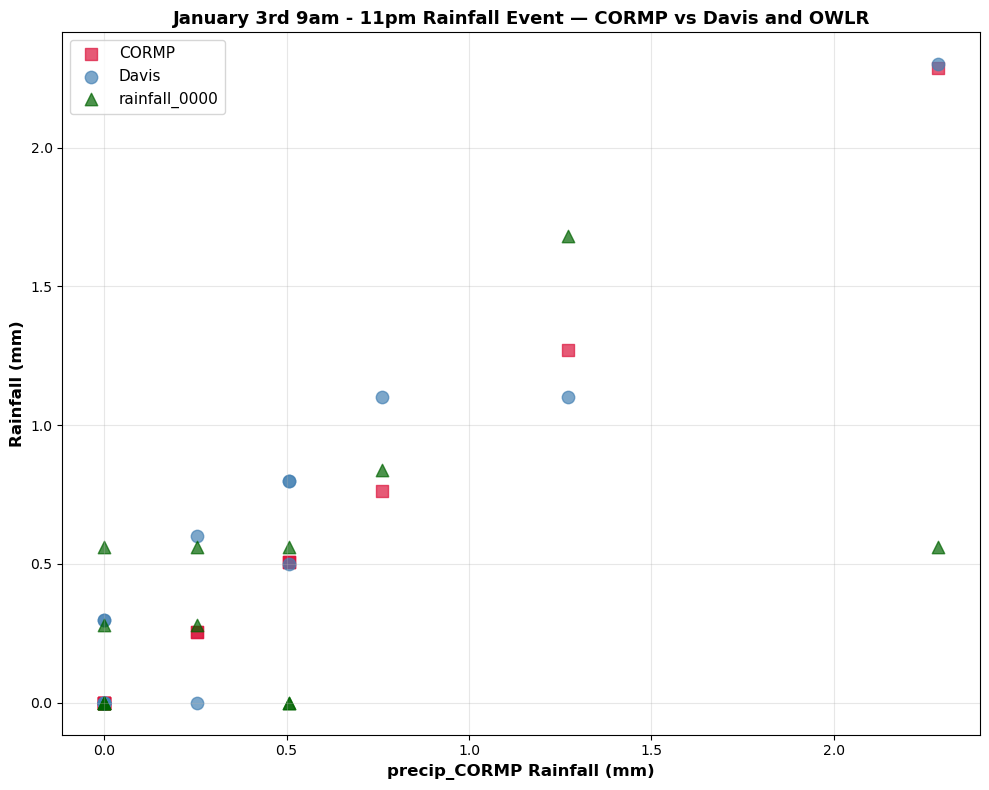


Summary Statistics for January 3rd 9am - 11pm:
CORMP - Min: 0.0000, Max: 2.2860, Mean: 0.4233
Davis - Min: 0.0000, Max: 2.3000, Mean: 0.5200
rainfall_0000 - Min: 0.0000, Max: 1.6800, Mean: 0.3800


In [26]:
# January 3rd 9am to 11pm — CORMP vs Davis and rainfall_0000 Comparison

print("=" * 70)
print("ANALYSIS 6: January 3rd 9am - 11pm — CORMP vs Davis and rainfall_0000")
print("=" * 70)

# Reload and process all three datasets for clean analysis
cormp_jan3 = load_and_process(file_1, assume_inches=True, already_hourly=False)
davis_jan3 = load_and_process(file_2, assume_inches=False, already_hourly=False)
rain0_jan3 = load_and_process(file_3, assume_inches=False, already_hourly=True, parse_embedded_string=True)

jan3_start = pd.to_datetime('2026-01-03 09:00')
jan3_end = pd.to_datetime('2026-01-03 23:00')

cormp_jan3 = cormp_jan3[(cormp_jan3['datetime'] >= jan3_start) & (cormp_jan3['datetime'] <= jan3_end)].reset_index(drop=True)
davis_jan3 = davis_jan3[(davis_jan3['datetime'] >= jan3_start) & (davis_jan3['datetime'] <= jan3_end)].reset_index(drop=True)
rain0_jan3 = rain0_jan3[(rain0_jan3['datetime'] >= jan3_start) & (rain0_jan3['datetime'] <= jan3_end)].reset_index(drop=True)

print(f"\nJanuary 3rd 9am - 11pm Data:")
print(f"  CORMP records: {len(cormp_jan3)}")
print(f"  Davis records: {len(davis_jan3)}")
print(f"  rainfall_0000 records: {len(rain0_jan3)}")

# Round all to nearest HOUR to align hourly data
cormp_jan3['datetime'] = cormp_jan3['datetime'].dt.floor('h')
davis_jan3['datetime'] = davis_jan3['datetime'].dt.floor('h')
rain0_jan3['datetime'] = rain0_jan3['datetime'].dt.floor('h')

# Merge all three datasets on datetime
merged_jan3 = pd.merge(cormp_jan3, davis_jan3, on='datetime', how='outer', suffixes=('_cormp','_davis'))
merged_jan3 = pd.merge(merged_jan3, rain0_jan3, on='datetime', how='outer')
merged_jan3 = merged_jan3.rename(columns={'rain_mm': 'rain_mm_rain0'})

print(f"\nMerged dataset shape: {merged_jan3.shape}")

# Create scatter plot: CORMP (X-axis) vs Davis, rainfall_0000, and CORMP (Y-axis)
print(f"\nGenerating scatter plot...")
plt.figure(figsize=(10, 8))

if not merged_jan3.empty:
    # Plot CORMP data (diagonal reference)
    cormp_data = merged_jan3[merged_jan3['rain_mm_cormp'].notna()]
    if not cormp_data.empty:
        plt.scatter(cormp_data['rain_mm_cormp'], cormp_data['rain_mm_cormp'], 
                   s=80, alpha=0.7, color='crimson', label='CORMP', marker='s')
        print(f"  Plotted {len(cormp_data)} CORMP data points")
    
    # Plot Davis data
    davis_data = merged_jan3[merged_jan3['rain_mm_davis'].notna()]
    if not davis_data.empty:
        plt.scatter(davis_data['rain_mm_cormp'], davis_data['rain_mm_davis'], 
                   s=80, alpha=0.7, color='steelblue', label='Davis', marker='o')
        print(f"  Plotted {len(davis_data)} Davis data points")
    
    # Plot rainfall_0000 data
    rain0_data = merged_jan3[merged_jan3['rain_mm_rain0'].notna()]
    if not rain0_data.empty:
        plt.scatter(rain0_data['rain_mm_cormp'], rain0_data['rain_mm_rain0'], 
                   s=80, alpha=0.7, color='darkgreen', label='rainfall_0000', marker='^')
        print(f"  Plotted {len(rain0_data)} rainfall_0000 data points")

plt.xlabel('precip_CORMP Rainfall (mm)', fontsize=12, fontweight='bold')
plt.ylabel('Rainfall (mm)', fontsize=12, fontweight='bold')
plt.title('January 3rd 9am - 11pm Rainfall Event — CORMP vs Davis and OWLR', fontsize=13, fontweight='bold')
plt.legend(loc='upper left', fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Print summary statistics
print("\n" + "=" * 70)
print("Summary Statistics for January 3rd 9am - 11pm:")
print("=" * 70)
if 'rain_mm_cormp' in merged_jan3.columns:
    print(f"CORMP - Min: {merged_jan3['rain_mm_cormp'].min():.4f}, Max: {merged_jan3['rain_mm_cormp'].max():.4f}, Mean: {merged_jan3['rain_mm_cormp'].mean():.4f}")
if 'rain_mm_davis' in merged_jan3.columns:
    print(f"Davis - Min: {merged_jan3['rain_mm_davis'].min():.4f}, Max: {merged_jan3['rain_mm_davis'].max():.4f}, Mean: {merged_jan3['rain_mm_davis'].mean():.4f}")
if 'rain_mm_rain0' in merged_jan3.columns:
    print(f"rainfall_0000 - Min: {merged_jan3['rain_mm_rain0'].min():.4f}, Max: {merged_jan3['rain_mm_rain0'].max():.4f}, Mean: {merged_jan3['rain_mm_rain0'].mean():.4f}")

ANALYSIS 7: January 25th 7am - January 26th 11am — CORMP vs Davis and rainfall_0000

January 25th 7am - January 26th 11am Data:
  CORMP records: 29
  Davis records: 29
  rainfall_0000 records: 28

Merged dataset shape: (29, 9)

Generating scatter plot...
  Plotted 29 CORMP data points
  Plotted 29 Davis data points
  Plotted 28 rainfall_0000 data points


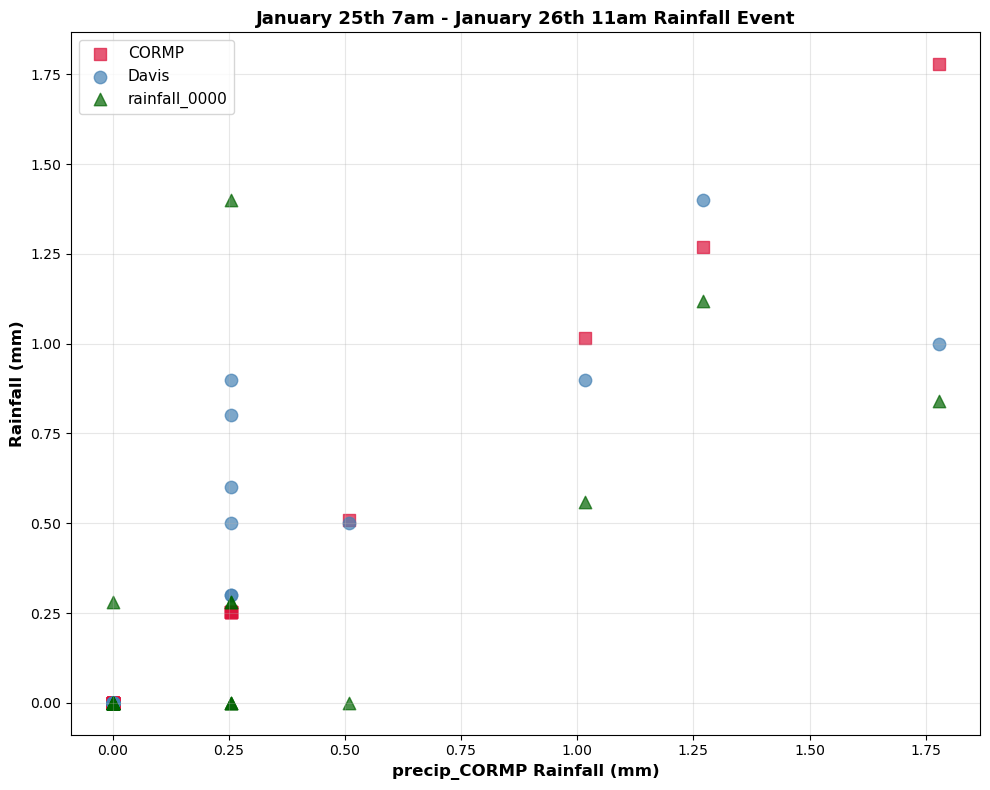


Summary Statistics for January 25th 7am - January 26th 11am:
CORMP - Min: 0.0000, Max: 1.7780, Mean: 0.2102
Davis - Min: 0.0000, Max: 1.4000, Mean: 0.2483
rainfall_0000 - Min: 0.0000, Max: 1.4000, Mean: 0.1700


In [27]:
# January 25th 7am to January 26th 11am — CORMP vs Davis and rainfall_0000 Comparison

print("=" * 70)
print("ANALYSIS 7: January 25th 7am - January 26th 11am — CORMP vs Davis and rainfall_0000")
print("=" * 70)

# Reload and process all three datasets for clean analysis
cormp_jan25_26 = load_and_process(file_1, assume_inches=True, already_hourly=False)
davis_jan25_26 = load_and_process(file_2, assume_inches=False, already_hourly=False)
rain0_jan25_26 = load_and_process(file_3, assume_inches=False, already_hourly=True, parse_embedded_string=True)

jan25_start = pd.to_datetime('2026-01-25 07:00')
jan26_end = pd.to_datetime('2026-01-26 11:00')

cormp_jan25_26 = cormp_jan25_26[(cormp_jan25_26['datetime'] >= jan25_start) & (cormp_jan25_26['datetime'] <= jan26_end)].reset_index(drop=True)
davis_jan25_26 = davis_jan25_26[(davis_jan25_26['datetime'] >= jan25_start) & (davis_jan25_26['datetime'] <= jan26_end)].reset_index(drop=True)
rain0_jan25_26 = rain0_jan25_26[(rain0_jan25_26['datetime'] >= jan25_start) & (rain0_jan25_26['datetime'] <= jan26_end)].reset_index(drop=True)

print(f"\nJanuary 25th 7am - January 26th 11am Data:")
print(f"  CORMP records: {len(cormp_jan25_26)}")
print(f"  Davis records: {len(davis_jan25_26)}")
print(f"  rainfall_0000 records: {len(rain0_jan25_26)}")

# Round all to nearest HOUR to align hourly data
cormp_jan25_26['datetime'] = cormp_jan25_26['datetime'].dt.floor('h')
davis_jan25_26['datetime'] = davis_jan25_26['datetime'].dt.floor('h')
rain0_jan25_26['datetime'] = rain0_jan25_26['datetime'].dt.floor('h')

# Merge all three datasets on datetime
merged_jan25_26 = pd.merge(cormp_jan25_26, davis_jan25_26, on='datetime', how='outer', suffixes=('_cormp','_davis'))
merged_jan25_26 = pd.merge(merged_jan25_26, rain0_jan25_26, on='datetime', how='outer')
merged_jan25_26 = merged_jan25_26.rename(columns={'rain_mm': 'rain_mm_rain0'})

print(f"\nMerged dataset shape: {merged_jan25_26.shape}")

# Create scatter plot: CORMP (X-axis) vs Davis, rainfall_0000, and CORMP (Y-axis)
print(f"\nGenerating scatter plot...")
plt.figure(figsize=(10, 8))

if not merged_jan25_26.empty:
    # Plot CORMP data (diagonal reference)
    cormp_data = merged_jan25_26[merged_jan25_26['rain_mm_cormp'].notna()]
    if not cormp_data.empty:
        plt.scatter(cormp_data['rain_mm_cormp'], cormp_data['rain_mm_cormp'], 
                   s=80, alpha=0.7, color='crimson', label='CORMP', marker='s')
        print(f"  Plotted {len(cormp_data)} CORMP data points")
    
    # Plot Davis data
    davis_data = merged_jan25_26[merged_jan25_26['rain_mm_davis'].notna()]
    if not davis_data.empty:
        plt.scatter(davis_data['rain_mm_cormp'], davis_data['rain_mm_davis'], 
                   s=80, alpha=0.7, color='steelblue', label='Davis', marker='o')
        print(f"  Plotted {len(davis_data)} Davis data points")
    
    # Plot rainfall_0000 data
    rain0_data = merged_jan25_26[merged_jan25_26['rain_mm_rain0'].notna()]
    if not rain0_data.empty:
        plt.scatter(rain0_data['rain_mm_cormp'], rain0_data['rain_mm_rain0'], 
                   s=80, alpha=0.7, color='darkgreen', label='rainfall_0000', marker='^')
        print(f"  Plotted {len(rain0_data)} rainfall_0000 data points")

plt.xlabel('precip_CORMP Rainfall (mm)', fontsize=12, fontweight='bold')
plt.ylabel('Rainfall (mm)', fontsize=12, fontweight='bold')
plt.title('January 25th 7am - January 26th 11am Rainfall Event', fontsize=13, fontweight='bold')
plt.legend(loc='upper left', fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Print summary statistics
print("\n" + "=" * 70)
print("Summary Statistics for January 25th 7am - January 26th 11am:")
print("=" * 70)
if 'rain_mm_cormp' in merged_jan25_26.columns:
    print(f"CORMP - Min: {merged_jan25_26['rain_mm_cormp'].min():.4f}, Max: {merged_jan25_26['rain_mm_cormp'].max():.4f}, Mean: {merged_jan25_26['rain_mm_cormp'].mean():.4f}")
if 'rain_mm_davis' in merged_jan25_26.columns:
    print(f"Davis - Min: {merged_jan25_26['rain_mm_davis'].min():.4f}, Max: {merged_jan25_26['rain_mm_davis'].max():.4f}, Mean: {merged_jan25_26['rain_mm_davis'].mean():.4f}")
if 'rain_mm_rain0' in merged_jan25_26.columns:
    print(f"rainfall_0000 - Min: {merged_jan25_26['rain_mm_rain0'].min():.4f}, Max: {merged_jan25_26['rain_mm_rain0'].max():.4f}, Mean: {merged_jan25_26['rain_mm_rain0'].mean():.4f}")

ANALYSIS 8: February 4th 2pm - February 5th 8am — CORMP vs Davis and rainfall_0000

February 4th 2pm - February 5th 8am Data:
  CORMP records: 19
  Davis records: 17
  rainfall_0000 records: 18

Merged dataset shape: (19, 9)

Generating scatter plot...
  Plotted 19 CORMP data points
  Plotted 17 Davis data points
  Plotted 18 rainfall_0000 data points


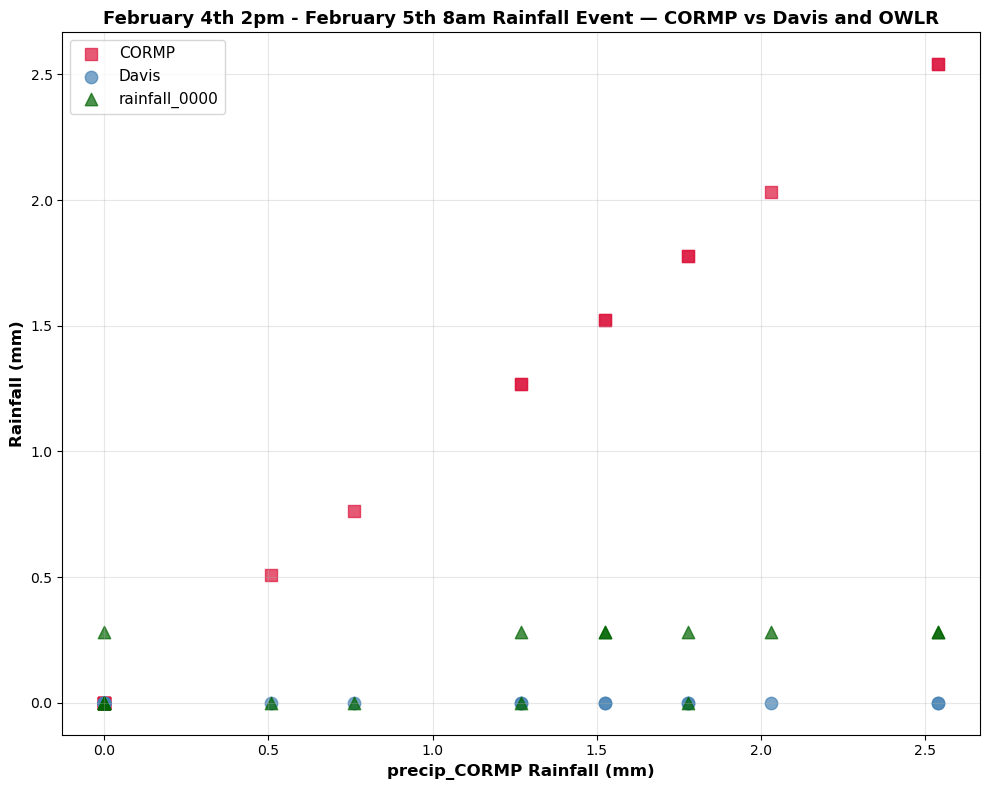


Summary Statistics for February 4th 2pm - February 5th 8am:
CORMP - Min: 0.0000, Max: 2.5400, Mean: 0.9224
Davis - Min: 0.0000, Max: 0.0000, Mean: 0.0000
rainfall_0000 - Min: 0.0000, Max: 0.2800, Mean: 0.1244


In [ ]:
# February 4th 2pm to February 5th 8am — CORMP vs Davis and rainfall_0000 Comparison

print("=" * 70)
print("ANALYSIS 8: February 4th 2pm - February 5th 8am — CORMP vs Davis and rainfall_0000")
print("=" * 70)

# Reload and process all three datasets for clean analysis
cormp_feb4_5 = load_and_process(file_1, assume_inches=True, already_hourly=False)
davis_feb4_5 = load_and_process(file_2, assume_inches=False, already_hourly=False)
rain0_feb4_5 = load_and_process(file_3, assume_inches=False, already_hourly=True, parse_embedded_string=True)

feb4_start = pd.to_datetime('2026-02-04 14:00')
feb5_end = pd.to_datetime('2026-02-05 08:00')

cormp_feb4_5 = cormp_feb4_5[(cormp_feb4_5['datetime'] >= feb4_start) & (cormp_feb4_5['datetime'] <= feb5_end)].reset_index(drop=True)
davis_feb4_5 = davis_feb4_5[(davis_feb4_5['datetime'] >= feb4_start) & (davis_feb4_5['datetime'] <= feb5_end)].reset_index(drop=True)
rain0_feb4_5 = rain0_feb4_5[(rain0_feb4_5['datetime'] >= feb4_start) & (rain0_feb4_5['datetime'] <= feb5_end)].reset_index(drop=True)

print(f"\nFebruary 4th 2pm - February 5th 8am Data:")
print(f"  CORMP records: {len(cormp_feb4_5)}")
print(f"  Davis records: {len(davis_feb4_5)}")
print(f"  rainfall_0000 records: {len(rain0_feb4_5)}")

# Round all to nearest HOUR to align hourly data
cormp_feb4_5['datetime'] = cormp_feb4_5['datetime'].dt.floor('h')
davis_feb4_5['datetime'] = davis_feb4_5['datetime'].dt.floor('h')
rain0_feb4_5['datetime'] = rain0_feb4_5['datetime'].dt.floor('h')

# Merge all three datasets on datetime
merged_feb4_5 = pd.merge(cormp_feb4_5, davis_feb4_5, on='datetime', how='outer', suffixes=('_cormp','_davis'))
merged_feb4_5 = pd.merge(merged_feb4_5, rain0_feb4_5, on='datetime', how='outer')
merged_feb4_5 = merged_feb4_5.rename(columns={'rain_mm': 'rain_mm_rain0'})

print(f"\nMerged dataset shape: {merged_feb4_5.shape}")

# Create scatter plot: CORMP (X-axis) vs Davis, rainfall_0000, and CORMP (Y-axis)
print(f"\nGenerating scatter plot...")
plt.figure(figsize=(10, 8))

if not merged_feb4_5.empty:
    # Plot CORMP data (diagonal reference)
    cormp_data = merged_feb4_5[merged_feb4_5['rain_mm_cormp'].notna()]
    if not cormp_data.empty:
        plt.scatter(cormp_data['rain_mm_cormp'], cormp_data['rain_mm_cormp'], 
                   s=80, alpha=0.7, color='crimson', label='CORMP', marker='s')
        print(f"  Plotted {len(cormp_data)} CORMP data points")
    
    # Plot Davis data
    davis_data = merged_feb4_5[merged_feb4_5['rain_mm_davis'].notna()]
    if not davis_data.empty:
        plt.scatter(davis_data['rain_mm_cormp'], davis_data['rain_mm_davis'], 
                   s=80, alpha=0.7, color='steelblue', label='Davis', marker='o')
        print(f"  Plotted {len(davis_data)} Davis data points")
    
    # Plot rainfall_0000 data
    rain0_data = merged_feb4_5[merged_feb4_5['rain_mm_rain0'].notna()]
    if not rain0_data.empty:
        plt.scatter(rain0_data['rain_mm_cormp'], rain0_data['rain_mm_rain0'], 
                   s=80, alpha=0.7, color='darkgreen', label='rainfall_0000', marker='^')
        print(f"  Plotted {len(rain0_data)} rainfall_0000 data points")

plt.xlabel('precip_CORMP Rainfall (mm)', fontsize=12, fontweight='bold')
plt.ylabel('Rainfall (mm)', fontsize=12, fontweight='bold')
plt.title('February 4th 2pm - February 5th 8am Rainfall Event — CORMP vs Davis and OWLR', fontsize=13, fontweight='bold')
plt.legend(loc='upper left', fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Print summary statistics
print("\n" + "=" * 70)
print("Summary Statistics for February 4th 2pm - February 5th 8am:")
print("=" * 70)
if 'rain_mm_cormp' in merged_feb4_5.columns:
    print(f"CORMP - Min: {merged_feb4_5['rain_mm_cormp'].min():.4f}, Max: {merged_feb4_5['rain_mm_cormp'].max():.4f}, Mean: {merged_feb4_5['rain_mm_cormp'].mean():.4f}")
if 'rain_mm_davis' in merged_feb4_5.columns:
    print(f"Davis - Min: {merged_feb4_5['rain_mm_davis'].min():.4f}, Max: {merged_feb4_5['rain_mm_davis'].max():.4f}, Mean: {merged_feb4_5['rain_mm_davis'].mean():.4f}")
if 'rain_mm_rain0' in merged_feb4_5.columns:
    print(f"rainfall_0000 - Min: {merged_feb4_5['rain_mm_rain0'].min():.4f}, Max: {merged_feb4_5['rain_mm_rain0'].max():.4f}, Mean: {merged_feb4_5['rain_mm_rain0'].mean():.4f}")